In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta
import contextily as ctx

In [2]:
plt.style.use('ggplot')

In [3]:
pipe_ind = 54468
intake_ind = 52556

In [4]:
# Load dataset
ds = xr.open_mfdataset('../run-output/pipe_ave/adamselv_v01_000*.nc', decode_times=False, concat_dim='time', combine='nested')

In [89]:
xpipe = ds['x'].isel(node=pipe_ind).compute().item()
ypipe = ds['y'].isel(node=pipe_ind).compute().item()

In [5]:
# Volume preprocessing
def unstructured_grid_volume(area, depth, surface_elevation, thickness):
    dz = np.abs(np.diff(thickness, axis=0))
    volume = (area * (surface_elevation + depth))
    depth_volume = volume[:, np.newaxis, :] * dz[np.newaxis, ...]
    return depth_volume

In [6]:
def correct_tracer_concentration(ds, tracer_name, vol, time,
                                 pipe_concentration=10, pipe_discharge=5.3/60,
                                 substance_concentration=10):
    """
    Applies mass correction to a tracer and returns corrected concentration.

    Parameters:
    -----------
    ds : xarray.Dataset
        Dataset containing the tracer.
    tracer_name : str
        Name of the tracer variable in the dataset (e.g. 'tracer1_c').
    vol : np.ndarray
        3D array of volume per cell [time, layers, elements].
    time : np.ndarray
        1D array of days since FVCOM origin
    pipe_concentration : float
        Tracer concentration at the pipe (default 10).
    pipe_discharge : float
        Discharge rate from the pipe in m³/s (default 5.3/60).
    
    Returns:
    --------
    tracer_conc : np.ndarray
        Corrected concentration of the tracer [time, layers, elements].
    """
    # Step 1. Correct for the mass of the tracer given pipe_concentration in the model (10 g/m3)
    tracer_mass = vol * ds[tracer_name].values
    tracer_mass_discharged = pipe_concentration * pipe_discharge * (np.abs(time[0] - time) * 86400)

    # model mass released at each timestep
    int_mass = tracer_mass.sum(axis=(-1, -2))
    # Avoid division by zero
    calibration = np.where(int_mass > 1e-9, tracer_mass_discharged / int_mass, 1)

    corrected_mass = tracer_mass * calibration[:, np.newaxis, np.newaxis]

    # Step 2. Recalculate for the mass of the substance
    substance_mass_discharged = substance_concentration * pipe_discharge * (np.abs(time[0] - time) * 86400)

    # mass released at each timestep
    int_corrected_mass = corrected_mass.sum(axis=(-1, -2))
    calibration_substance = np.where(int_corrected_mass > 1e-9,
                                 substance_mass_discharged / int_corrected_mass,
                                 1)
    corrected_substance_mass = corrected_mass * calibration_substance[:, np.newaxis, np.newaxis]

    tracer_conc = corrected_substance_mass / vol
    return tracer_conc

In [7]:
# Load required vars
area = ds['art1'].values
depth = ds['h'].values
surface_elevation = ds['zeta'].values
thickness = ds['siglev'].values
time = ds.time.values

# Calculate volume and mass
vol = unstructured_grid_volume(area, depth, surface_elevation, thickness)

In [8]:
# Step 1. Correct for the mass of the tracer given pipe_concentration in the model (10 g/m3)
tracer_mass = vol * ds['tracer1_c'].values
pipe_concentration=10
pipe_discharge=5.3/60
tracer_mass_discharged = pipe_concentration * pipe_discharge * (np.abs(time[0] - time) * 86400)

# model mass released at each timestep
int_mass = tracer_mass.sum(axis=(-1, -2))

In [9]:
vol[28,:,pipe_ind]

array([  6.60951719,   8.04639612,   9.78859358,  11.89758198,
        14.4455707 ,  17.51658033,  21.20719932,  25.62674315,
        30.89641694,  37.14693778,  44.51391541,  53.13014692,
        63.11390943,  74.55242373,  87.48004352, 101.85155422,
       117.51237799, 134.16949292, 151.36923952, 168.4902474 ,
       184.76036675, 199.3044206 , 211.22392384, 219.70108156,
       224.10976947, 224.10976947, 219.70108156, 211.22392384,
       199.3044206 , 184.76036675])

In [10]:
tracer1_conc = correct_tracer_concentration(ds, 'tracer1_c', vol, time)
tracer2_conc = correct_tracer_concentration(ds, 'tracer2_c', vol, time)

/var/folders/6l/bpcqsc4x3_ncpql2_wq5f8yw0000gn/T/ipykernel_1322/3076601091.py:34: RuntimeWarning: divide by zero encountered in divide
  calibration = np.where(int_mass > 1e-9, tracer_mass_discharged / int_mass, 1)
/var/folders/6l/bpcqsc4x3_ncpql2_wq5f8yw0000gn/T/ipykernel_1322/3076601091.py:34: RuntimeWarning: invalid value encountered in divide
  calibration = np.where(int_mass > 1e-9, tracer_mass_discharged / int_mass, 1)
/var/folders/6l/bpcqsc4x3_ncpql2_wq5f8yw0000gn/T/ipykernel_1322/3076601091.py:44: RuntimeWarning: divide by zero encountered in divide
  substance_mass_discharged / int_corrected_mass,
/var/folders/6l/bpcqsc4x3_ncpql2_wq5f8yw0000gn/T/ipykernel_1322/3076601091.py:44: RuntimeWarning: invalid value encountered in divide
  substance_mass_discharged / int_corrected_mass,


In [11]:
intake_ds = ds.isel(node=intake_ind)

In [12]:
inn_z = intake_ds['siglay'].values * intake_ds['h'].isel(time=0).values

In [13]:
inn_z

array([ -0.04313042,  -0.13876762,  -0.25514988,  -0.39666307,
        -0.56856538,  -0.77713447,  -1.02982658,  -1.33544158,
        -1.70428359,  -2.14830066,  -2.68117875,  -3.3183553 ,
        -4.07690616,  -4.97524813,  -6.03259137,  -7.26807515,
        -8.699535  , -10.34188563, -12.20516929, -14.29241311,
       -16.59755081, -19.10376647, -21.78267013, -24.59467225,
       -27.49076099, -30.41561863, -33.31170736, -36.12370948,
       -38.80261314, -41.3088288 ])

In [15]:
inn_tracer_1 = tracer1_conc[:,-1,intake_ind]
inn_tracer_2 = tracer2_conc[:,-1,intake_ind]

In [17]:
dilution1 = np.where(inn_tracer_1 > 1e-9,
                                 10/inn_tracer_1,
                                 1e9) 
dilution2 = np.where(inn_tracer_2 > 1e-9,
                                 10/inn_tracer_2,
                                 1e9) 

/var/folders/6l/bpcqsc4x3_ncpql2_wq5f8yw0000gn/T/ipykernel_1322/3247152258.py:2: RuntimeWarning: divide by zero encountered in divide
  10/inn_tracer_1,
/var/folders/6l/bpcqsc4x3_ncpql2_wq5f8yw0000gn/T/ipykernel_1322/3247152258.py:5: RuntimeWarning: divide by zero encountered in divide
  10/inn_tracer_2,


In [18]:
dilution1[dilution1 > 1e6] = np.nan
dilution2[dilution2 > 1e6] = np.nan

In [19]:
# FVCOM origin date
fvcom_origin = datetime(1858, 11, 17)
dates = [fvcom_origin + timedelta(days=d) for d in time]

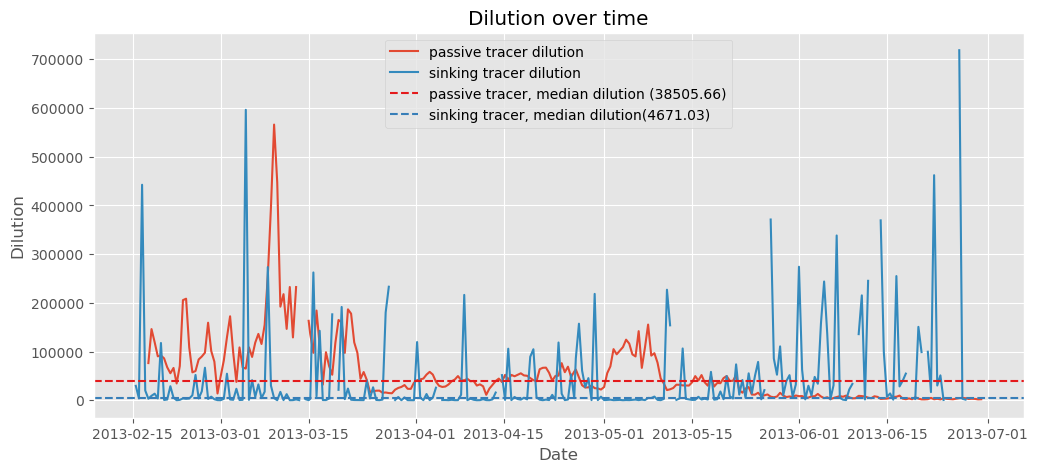

In [25]:
fig, ax = plt.subplots(figsize=(12,5))

# Plot original data
ax.plot(dates, dilution1, label='passive tracer dilution')
ax.plot(dates, dilution2, label='sinking tracer dilution')

# Calculate median values
median_passive = np.nanmedian(dilution1)
median_sinking = np.nanmedian(dilution2)

ax.axhline(median_passive, color='#e41a1c', linestyle='--', linewidth=1.5,
           label=f'passive tracer, median dilution ({median_passive:.2f})')
ax.axhline(median_sinking, color='#377eb8', linestyle='--', linewidth=1.5,
           label=f'sinking tracer, median dilution({median_sinking:.2f})')

# Optional: Improve readability
ax.legend()
ax.set_xlabel('Date')
ax.set_ylabel('Dilution')
ax.set_title('Dilution over time')

plt.savefig('dilution_intake.png', dpi=200, bbox_inches='tight')

In [20]:
dsnode = ds.isel(node=slice(pipe_ind-17, pipe_ind+20))

In [213]:
#target_ind = [0,1,2,3,4,5,6,7,8,9,10,11,12,16,17,18,19,20]
target_ind = np.array([53601, 53763, 53918, 54066, 54208, 54402, 54468, 54531, 54591, 54694, 54744])

In [214]:
dsout = ds.sel(node=target_ind)

In [215]:
#nodes = dsnode.node.values
#x = dsnode.x.values
#y = dsnode.y.values

x = dsout.x.values - xpipe
y = dsout.y.values - ypipe

In [216]:
tracer1raw = dsout['tracer1_c'].values
tracer2raw = dsout['tracer2_c'].values

temp = dsout['temp'].values
salt = dsout['salinity'].values

In [217]:
zout = dsout['siglay'].values * dsout['h'].isel(time=0).values

In [218]:
zout.shape

(30, 11)

In [219]:
tracer1 = tracer1_conc[:,:,target_ind]

tracer2 = tracer2_conc[:,:,target_ind]

In [220]:
yout = np.tile(y[:,np.newaxis], 30).T

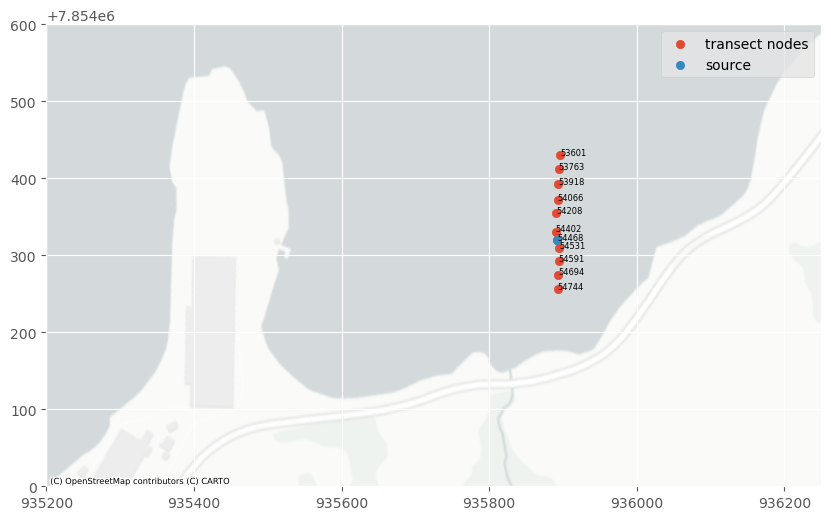

In [227]:
fig, ax = plt.subplots(figsize=(10,6))
ax.set_xlim(9.352e5, 9.3625e5)
ax.set_ylim(7.854e6, 7.8546e6)
ax.scatter(x+xpipe, y+ypipe, label='transect nodes')
for i, node in enumerate(target_ind):
    plt.annotate(str(node), (x[i]+xpipe, y[i]+ypipe), fontsize=6)
ax.scatter(xpipe, ypipe, label='source')
plt.legend()
ctx.add_basemap(ax, crs='EPSG:32633', source=ctx.providers.CartoDB.Positron, attribution_size=6)
plt.savefig('transect_map.png', dpi=200, bbox_inches='tight')

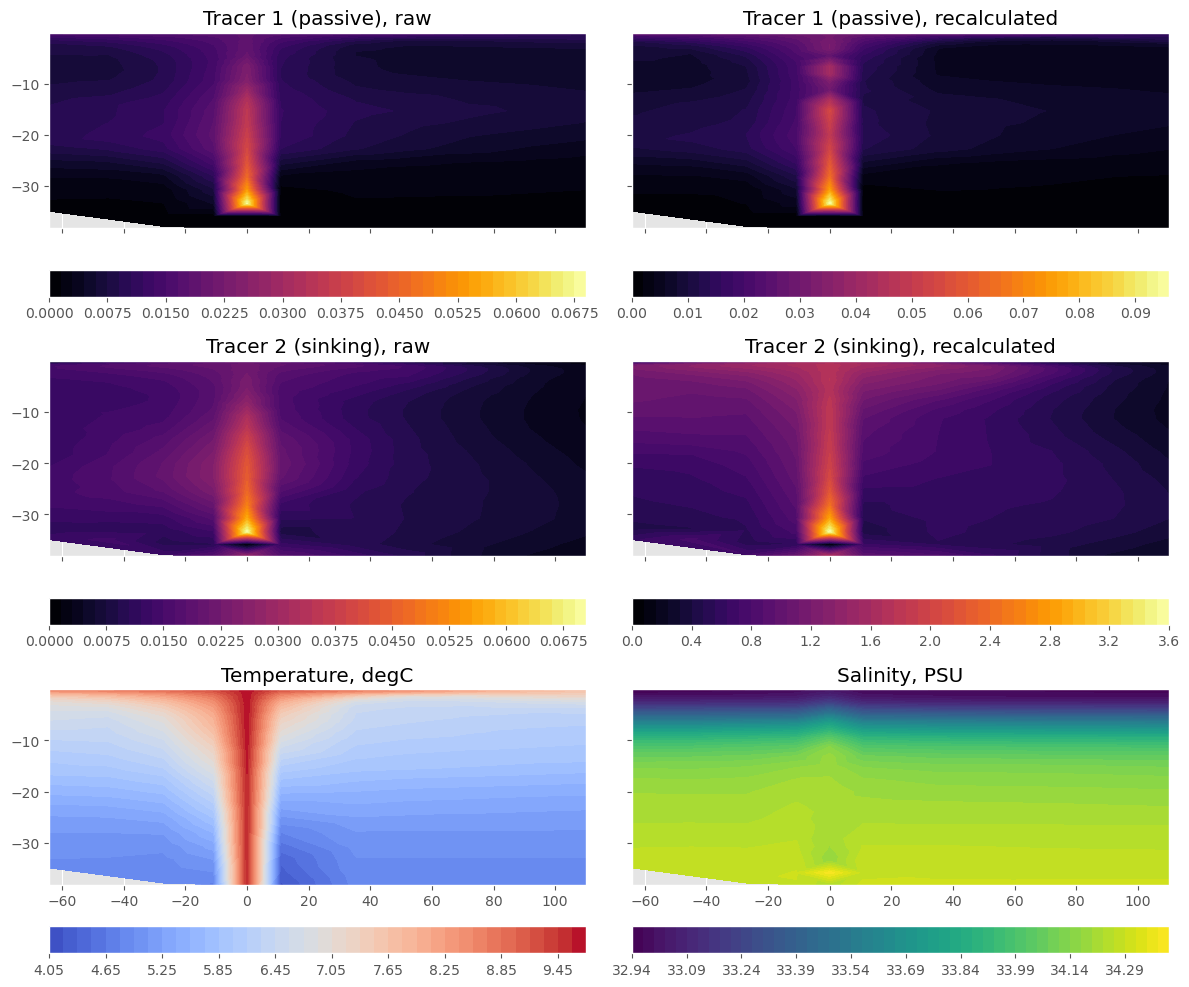

In [228]:
fig, axs = plt.subplots(3, 2, figsize=(12,10), sharex=True, sharey=True)
t1 = axs[0,0].tricontourf(yout.ravel(), zout.ravel(), np.nanmean(tracer1raw, axis=0).ravel(), levels=50, cmap='inferno')
axs[0,0].set_title('Tracer 1 (passive), raw')
fig.colorbar(t1, location='bottom')

t2 = axs[0,1].tricontourf(yout.ravel(), zout.ravel(), np.nanmean(tracer1, axis=0).ravel(), levels=50, cmap='inferno')
axs[0,1].set_title('Tracer 1 (passive), recalculated')
fig.colorbar(t2, location='bottom')

t11 = axs[1,0].tricontourf(yout.ravel(), zout.ravel(), np.nanmean(tracer2raw, axis=0).ravel(), levels=50, cmap='inferno')
axs[1,0].set_title('Tracer 2 (sinking), raw')
fig.colorbar(t11, location='bottom')

t22 = axs[1,1].tricontourf(yout.ravel(), zout.ravel(), np.nanmean(tracer2, axis=0).ravel(), levels=50, cmap='inferno')
axs[1,1].set_title('Tracer 2 (sinking), recalculated')
fig.colorbar(t22, location='bottom')


t3 = axs[2,0].tricontourf(yout.ravel(), zout.ravel(), np.nanmean(temp, axis=0).ravel(), levels=50, cmap='coolwarm')
axs[2,0].set_title('Temperature, degC')
fig.colorbar(t3, location='bottom')

t4 = axs[2,1].tricontourf(yout.ravel(), zout.ravel(), np.nanmean(salt, axis=0).ravel(), levels=50, cmap='viridis')
axs[2,1].set_title('Salinity, PSU')
fig.colorbar(t4, location='bottom')

plt.tight_layout()
plt.savefig('transect_out.png', dpi=200, bbox_inches='tight')

In [102]:
xpipe

935892.177156

In [103]:
ypipe

7854319.902487

In [145]:
x_min, x_max = xpipe - 5, xpipe + 5
y_min, y_max = ypipe - 120, ypipe + 120

# Step 1: Find node indices where x and y fall within the box
mask = (ds.x >= x_min) & (ds.x <= x_max) & (ds.y >= y_min) & (ds.y <= y_max)

In [146]:
mask.compute().values

array([False, False, False, ..., False, False, False], shape=(55089,))

In [147]:
# Step 2: Get node indices (if you need actual indices)
selected_nodes = ds.x['node'].values[mask.compute().values]

# Step 3: Filter the dataset along the 'node' dimension using the mask
dso = ds.sel(node=selected_nodes)

In [148]:
selected_nodes

array([53519, 53601, 53683, 53763, 53841, 53918, 53993, 54066, 54137,
       54208, 54274, 54336, 54341, 54402, 54468, 54531, 54590, 54591,
       54647, 54694, 54743, 54744, 54785, 54831, 54832, 54873, 54875,
       54876])

In [149]:
nodeso = dso.node.values
xo = dso.x.values - xpipe
yo = dso.y.values - ypipe

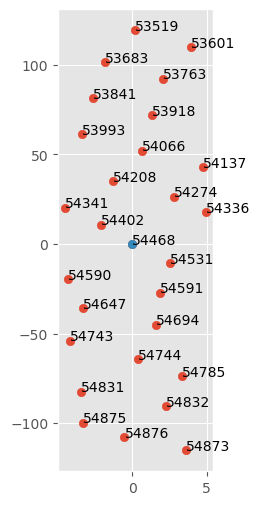

In [152]:
fig = plt.figure(figsize=(2,6))
plt.scatter(xo, yo)
for i, node in enumerate(selected_nodes):
    plt.annotate(str(node), (xo[i], yo[i]))
plt.scatter(0, 0)

In [212]:
[53601, 53763, 53918, 54066, 54208, 54402, 54468, 54531, 54591, 54694, 54744]

[53601, 53763, 53918, 54066, 54208, 54402, 54468, 54531, 54591, 54694, 54744]

In [56]:
tracer1 = dsout['tracer1_c'].values

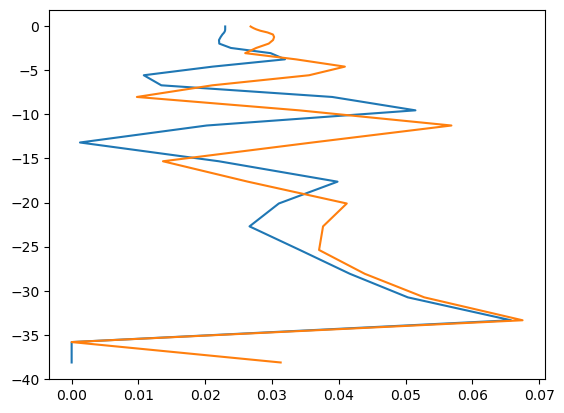

In [46]:
t = 30
plt.plot(tracer_1[t,:], z)
plt.plot(tracer_2[t,:], z)